In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
DATA_PATH = "../data/raw"

daily = pd.read_csv(f"{DATA_PATH}/daily_dataset.csv")
weather = pd.read_csv(f"{DATA_PATH}/weather_daily_darksky.csv")
households = pd.read_csv(f"{DATA_PATH}/informations_households.csv")
holidays = pd.read_csv(f"{DATA_PATH}/uk_bank_holidays.csv")

In [3]:
daily["day"] = pd.to_datetime(daily["day"])
weather["time"] = pd.to_datetime(weather["time"])

In [4]:
print("="*60)
print("Daily Dataset")
print(daily.head())

print("="*60)
print("Weather Dataset")
print(weather.head())

print("="*60)
print("Households Dataset")
print(households.head())

print("="*60)
print("Holiday Dataset")
print(holidays.head())

Daily Dataset
       LCLid        day  energy_median  energy_mean  energy_max  energy_count  \
0  MAC000131 2011-12-15         0.4850     0.432045       0.868            22   
1  MAC000131 2011-12-16         0.1415     0.296167       1.116            48   
2  MAC000131 2011-12-17         0.1015     0.189812       0.685            48   
3  MAC000131 2011-12-18         0.1140     0.218979       0.676            48   
4  MAC000131 2011-12-19         0.1910     0.325979       0.788            48   

   energy_std  energy_sum  energy_min  
0    0.239146       9.505       0.072  
1    0.281471      14.216       0.031  
2    0.188405       9.111       0.064  
3    0.202919      10.511       0.065  
4    0.259205      15.647       0.066  
Weather Dataset
   temperatureMax   temperatureMaxTime  windBearing                 icon  \
0           11.96  2011-11-11 23:00:00          123                  fog   
1            8.59  2011-12-11 14:00:00          198    partly-cloudy-day   
2           10.

In [5]:
print(daily.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510433 entries, 0 to 3510432
Data columns (total 9 columns):
 #   Column         Dtype         
---  ------         -----         
 0   LCLid          object        
 1   day            datetime64[ns]
 2   energy_median  float64       
 3   energy_mean    float64       
 4   energy_max     float64       
 5   energy_count   int64         
 6   energy_std     float64       
 7   energy_sum     float64       
 8   energy_min     float64       
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 241.0+ MB
None


In [6]:
daily.describe().T

,count,mean,min,25%,50%,75%,max,std
day,3510433,2013-03-27 21:09:43.463407360,2011-11-23 00:00:00,2012-10-21 00:00:00,2013-03-30 00:00:00,2013-09-10 00:00:00,2014-02-28 00:00:00,NaN
energy_median,3510403.0,0.158739,0.0,0.067,0.1145,0.191,6.9705,0.170186
energy_mean,3510403.0,0.21173,0.0,0.098083,0.163292,0.262458,6.92825,0.190846
energy_max,3510403.0,0.834521,0.0,0.346,0.688,1.128,10.761,0.668316
energy_count,3510433.0,47.803636,0.0,48.0,48.0,48.0,48.0,2.810982
energy_std,3499102.0,0.172667,0.0,0.069116,0.132791,0.229312,4.024569,0.153121
energy_sum,3510403.0,10.124143,0.0,4.682,7.815,12.569,332.556001,9.128793
energy_min,3510403.0,0.059626,0.0,0.02,0.039,0.071,6.524,0.087013


In [7]:
print("Rows :", daily.shape[0])
print("Columns :", daily.shape[1])
print("Unique Households :", daily["LCLid"].nunique())
print("Start Date :", daily["day"].min())
print("End Date :", daily["day"].max())
print("Total Days :", daily["day"].nunique())

Rows : 3510433
Columns : 9
Unique Households : 5566
Start Date : 2011-11-23 00:00:00
End Date : 2014-02-28 00:00:00
Total Days : 829


In [8]:
daily.isnull().sum()

LCLid                0
day                  0
energy_median       30
energy_mean         30
energy_max          30
energy_count         0
energy_std       11331
energy_sum          30
energy_min          30
dtype: int64

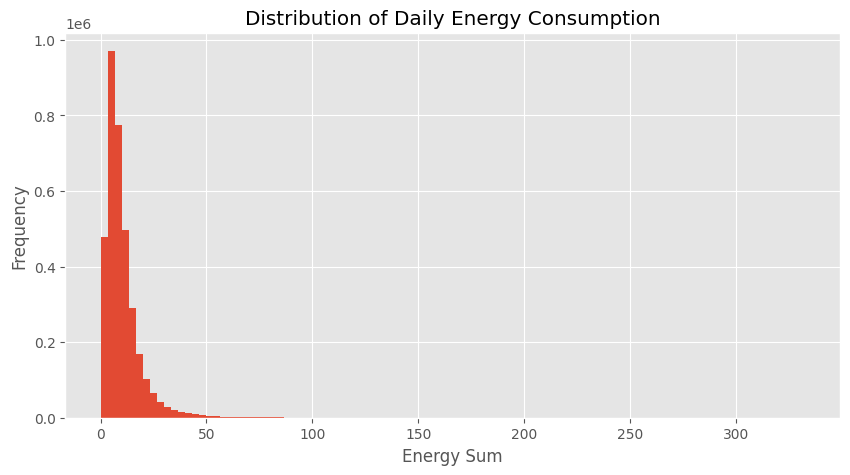

In [9]:
plt.figure(figsize=(10,5))

plt.hist(
    daily["energy_sum"].dropna(),
    bins=100
)

plt.title("Distribution of Daily Energy Consumption")
plt.xlabel("Energy Sum")
plt.ylabel("Frequency")

plt.show()

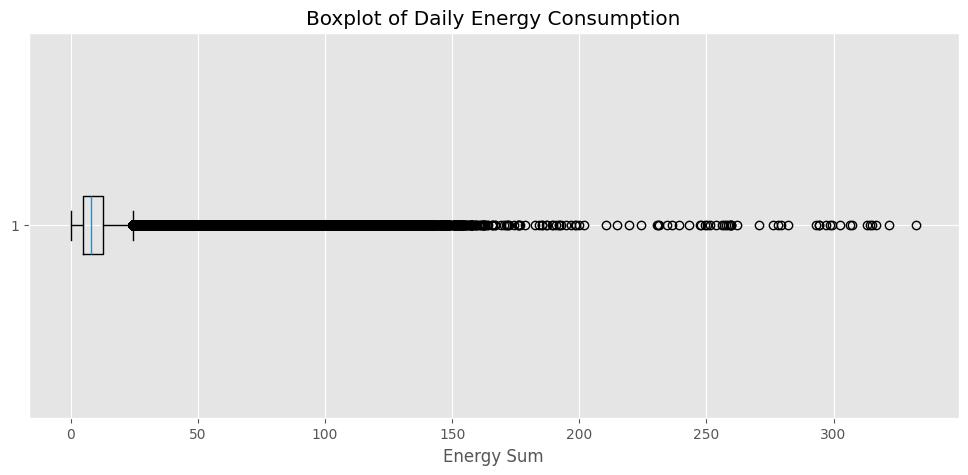

In [10]:
plt.figure(figsize=(12, 5))

plt.boxplot(
    daily["energy_sum"].dropna(),
    vert=False
)

plt.title("Boxplot of Daily Energy Consumption")
plt.xlabel("Energy Sum")

plt.show()

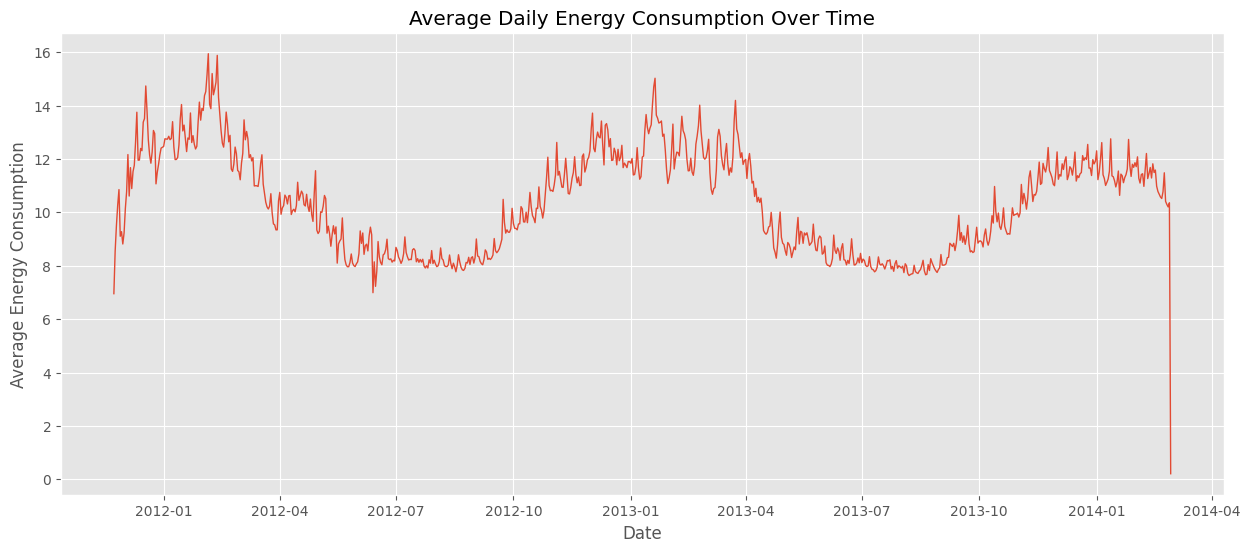

In [11]:
daily_trend = (
    daily.groupby("day")["energy_sum"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(15,6))

plt.plot(
    daily_trend["day"],
    daily_trend["energy_sum"],
    linewidth=1
)

plt.title("Average Daily Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Average Energy Consumption")

plt.show()

In [12]:
daily[daily["day"] == daily["day"].max()]

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min
806,MAC000131,2014-02-28,0.075,0.075,0.075,1,NaN,0.075,0.075
1613,MAC000132,2014-02-28,0.049,0.049,0.049,1,NaN,0.049,0.049
2434,MAC000221,2014-02-28,0.592,0.592,0.592,1,NaN,0.592,0.592
3255,MAC000228,2014-02-28,0.039,0.039,0.039,1,NaN,0.039,0.039
4076,MAC000234,2014-02-28,0.071,0.071,0.071,1,NaN,0.071,0.071
...,...,...,...,...,...,...,...,...,...
3507356,MAC004926,2014-02-28,0.033,0.033,0.033,1,NaN,0.033,0.033
3508127,MAC004932,2014-02-28,0.177,0.177,0.177,1,NaN,0.177,0.177
3508898,MAC004937,2014-02-28,0.084,0.084,0.084,1,NaN,0.084,0.084
3509666,MAC004965,2014-02-28,0.618,0.618,0.618,1,NaN,0.618,0.618


In [13]:
daily["energy_count"].value_counts().sort_index()

energy_count
0          30
1       11301
4           2
8           2
9           2
10          2
11          1
12          2
13          2
14          2
15         12
16         15
17         29
18         65
19        132
20        168
21        250
22        318
23        369
24        423
25        421
26        510
27        501
28        543
29        544
30        529
31        399
32        274
33         39
34         43
35         39
36         56
37         69
38         92
39        112
40        233
41        164
42        204
43        252
44        290
45        426
46       1005
47      21209
48    3469352
Name: count, dtype: int64

In [14]:
daily = daily[daily["energy_count"] == 48]

In [15]:
print("Shape :", daily.shape)
print("Unique Households :", daily["LCLid"].nunique())
print("Start Date :", daily["day"].min())
print("End Date :", daily["day"].max())

Shape : (3469352, 9)
Unique Households : 5560
Start Date : 2011-11-24 00:00:00
End Date : 2014-02-27 00:00:00


In [16]:
daily.isnull().sum()

LCLid            0
day              0
energy_median    0
energy_mean      0
energy_max       0
energy_count     0
energy_std       0
energy_sum       0
energy_min       0
dtype: int64

In [17]:
households.head()

,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0


In [18]:
merged = daily.merge(
    households,
    on="LCLid",
    how="left"
)

In [19]:
print(merged.shape)

(3469352, 13)


In [20]:
merged.head()

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min,stdorToU,Acorn,Acorn_grouped,file
0,MAC000131,2011-12-16,0.1415,0.296167,1.116,48,0.281471,14.216,0.031,Std,ACORN-E,Affluent,block_22
1,MAC000131,2011-12-17,0.1015,0.189812,0.685,48,0.188405,9.111,0.064,Std,ACORN-E,Affluent,block_22
2,MAC000131,2011-12-18,0.1140,0.218979,0.676,48,0.202919,10.511,0.065,Std,ACORN-E,Affluent,block_22
3,MAC000131,2011-12-19,0.1910,0.325979,0.788,48,0.259205,15.647,0.066,Std,ACORN-E,Affluent,block_22
4,MAC000131,2011-12-20,0.2180,0.357500,1.077,48,0.287597,17.160,0.066,Std,ACORN-E,Affluent,block_22


In [21]:
merged.isnull().sum()

LCLid            0
day              0
energy_median    0
energy_mean      0
energy_max       0
energy_count     0
energy_std       0
energy_sum       0
energy_min       0
stdorToU         0
Acorn            0
Acorn_grouped    0
file             0
dtype: int64

In [22]:
print("Merged day dtype:", merged["day"].dtype)
print("Weather time dtype:", weather["time"].dtype)

print("Merged date range:", merged["day"].min(), "to", merged["day"].max())
print("Weather date range:", weather["time"].min(), "to", weather["time"].max())

Merged day dtype: datetime64[ns]
Weather time dtype: datetime64[ns]
Merged date range: 2011-11-24 00:00:00 to 2014-02-27 00:00:00
Weather date range: 2011-11-01 00:00:00 to 2014-03-30 23:00:00


In [23]:
weather["day"] = weather["time"].dt.normalize()
merged["day"] = pd.to_datetime(merged["day"]).dt.normalize()

In [24]:
merged = merged.merge(
    weather,
    on="day",
    how="left"
)

In [29]:
# merged ko household-merge wali correct stage par wapas lao
merged = daily.merge(
    households,
    on="LCLid",
    how="left"
)

# weather ki correct date banao
weather["day"] = (
    pd.to_datetime(weather["time"], utc=True)
    .dt.tz_convert("Europe/London")
    .dt.tz_localize(None)
    .dt.normalize()
)

print("Duplicate weather days:", weather["day"].duplicated().sum())

Duplicate weather days: 0


In [30]:
merged = merged.merge(
    weather,
    on="day",
    how="left"
)

print("Merged shape:", merged.shape)

Merged shape: (3469352, 45)


In [31]:
weather_columns = weather.columns.drop(["time", "day"])

merged[weather_columns].isnull().sum()

temperatureMax                    0
temperatureMaxTime                0
windBearing                       0
icon                              0
dewPoint                          0
temperatureMinTime                0
cloudCover                     5076
windSpeed                         0
pressure                          0
apparentTemperatureMinTime        0
apparentTemperatureHigh           0
precipType                        0
visibility                        0
humidity                          0
apparentTemperatureHighTime       0
apparentTemperatureLow            0
apparentTemperatureMax            0
uvIndex                        5076
sunsetTime                        0
temperatureLow                    0
temperatureMin                    0
temperatureHigh                   0
sunriseTime                       0
temperatureHighTime               0
uvIndexTime                    5076
summary                           0
temperatureLowTime                0
apparentTemperatureMin      

In [32]:
merged["cloudCover"] = merged["cloudCover"].fillna(
    merged["cloudCover"].median()
)

merged["uvIndex"] = merged["uvIndex"].fillna(
    merged["uvIndex"].median()
)

In [33]:
merged["uvIndexTime"] = merged["uvIndexTime"].ffill()

In [34]:
merged.isnull().sum().sum()

0

In [35]:
merged.to_csv(
    "../data/processed/merged_dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
